# Sediment Porosity Workflow (Python)

Python workflow for sediment porosity processing and static inspection plots using NumPy, xarray, rasterio, and Matplotlib.

In [ ]:
import numpy as np
import rasterio
from rasterio.warp import transform, reproject, Resampling
from netCDF4 import Dataset
import matplotlib.pyplot as plt

from pathlib import Path
from datetime import datetime

from rasterio.transform import rowcol
from rasterio.warp import calculate_default_transform, reproject, Resampling

import os
import pandas as pd
import xarray as xr


# ------------------------------------------------------------
# Paths (standalone TIFF -> sediment_mud_fraction.nc workflow)
# ------------------------------------------------------------
setup_indir = Path('/export/lv9/user/qzhan/home/GETM_ERSEM_SETUPS/dws_500m/Input/') 
base_dir = Path('/export/lv9/user/qzhan/home/pre-processing/porosity/dws_500m/')
tif_path = base_dir / '2024_11_18_Franken_SuppInfo3B_BelowMurkyWaters_Silt.tif'
topo_nc = Path('/export/lv9/user/cgiannopoulos/home/pre-processing/bathymetry_resampling/topo_dws_500m.nc')
out_nc = base_dir / 'sediment_mud_fraction.nc'


print(f'TIFF path: {tif_path}')
print(f'Topo path: {topo_nc}')
print(f'Output  : {out_nc}')

TIFF path: /export/lv9/user/qzhan/home/pre-processing/porosity/dws_500m/2024_11_18_Franken_SuppInfo3B_BelowMurkyWaters_Silt.tif
Topo path: /export/lv9/user/cgiannopoulos/home/pre-processing/bathymetry_resampling/topo_dws_500m.nc
Output  : /export/lv9/user/qzhan/home/pre-processing/porosity/dws_500m/sediment_mud_fraction.nc


TIFF path: /export/lv9/user/qzhan/home/pre-processing/porosity/dws_500m/2024_11_18_Franken_SuppInfo3B_BelowMurkyWaters_Silt.tif
Topo path: /export/lv9/user/cgiannopoulos/home/pre-processing/bathymetry_resampling/topo_dws_500m.nc
Output  : /export/lv9/user/qzhan/home/pre-processing/porosity/dws_500m/sediment_mud_fraction.nc
TIFF CRS: EPSG:28992
GETM lon range: 4.029751300811768 6.784867286682129
GETM lat range: 52.49859619140625 53.75567626953125
Wrote NetCDF: /export/lv9/user/qzhan/home/pre-processing/porosity/dws_500m/sediment_mud_fraction.nc


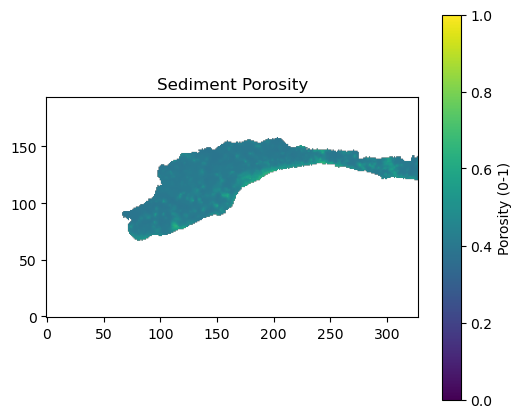

In [ ]:


# ------------------------------------------------------------
# 1) Load TIFF and GETM topology
# ------------------------------------------------------------
with rasterio.open(tif_path) as src:
    silt_crs = src.crs
    transform_src = src.transform
    src_nodata = src.nodata
    silt_data = src.read(1).astype('float32')

    if src_nodata is not None:
        silt_data[silt_data == src_nodata] = np.nan

    # ------------------------------------------------------------
    # 2) Reproject TIFF to EPSG:4326
# ------------------------------------------------------------
    dst_crs = 'EPSG:4326'
    transform_ll, width_ll, height_ll = calculate_default_transform(
        src.crs, dst_crs, src.width, src.height, *src.bounds
    )

    # Initialize with NaNs so out-of-domain pixels stay missing
    silt_ll = np.full((height_ll, width_ll), np.nan, dtype='float32')
    reproject(
        source=silt_data,
        destination=silt_ll,
        src_transform=transform_src,
        src_crs=src.crs,
        dst_transform=transform_ll,
        dst_crs=dst_crs,
        src_nodata=np.nan,
        dst_nodata=np.nan,
        resampling=Resampling.nearest,
    )

with Dataset(topo_nc, 'r') as nc:
    lonc = nc.variables['lonc'][:]
    latc = nc.variables['latc'][:]

dim_xc, dim_yc = lonc.shape

print('TIFF CRS:', silt_crs)
print('GETM lon range:', float(np.nanmin(lonc)), float(np.nanmax(lonc)))
print('GETM lat range:', float(np.nanmin(latc)), float(np.nanmax(latc)))

# ------------------------------------------------------------
# 3) Sample reprojected raster at GETM grid cell centers
# ------------------------------------------------------------
xy = np.column_stack([lonc.ravel(), latc.ravel()])
rows, cols = rowcol(transform_ll, xy[:, 0], xy[:, 1])
rows = np.asarray(rows)
cols = np.asarray(cols)

vals = np.full(len(rows), np.nan, dtype='float32')
in_bounds = (rows >= 0) & (rows < height_ll) & (cols >= 0) & (cols < width_ll)
vals[in_bounds] = silt_ll[rows[in_bounds], cols[in_bounds]]

silt_arr = vals.reshape(dim_xc, dim_yc)

# ------------------------------------------------------------
# 4) Handle NA and compute porosity
# ------------------------------------------------------------
fill_na_with = -999.0
silt_arr_filled = np.where(np.isnan(silt_arr), fill_na_with, silt_arr)

# R formula: porosity = 0.387 + 0.415 * (silt_fraction/100)
porosity_arr = 0.387 + 0.415 * (silt_arr_filled / 100.0)
porosity_arr = np.where(silt_arr_filled == fill_na_with, fill_na_with, porosity_arr)

# ------------------------------------------------------------
# 5) Write to NetCDF
# ------------------------------------------------------------
out_nc.parent.mkdir(parents=True, exist_ok=True)
with Dataset(out_nc, 'w', format='NETCDF4') as ncnew:
    ncnew.createDimension('xc', dim_xc)
    ncnew.createDimension('yc', dim_yc)

    lon_var = ncnew.createVariable('lonc', 'f4', ('xc', 'yc'), fill_value=1e20)
    lat_var = ncnew.createVariable('latc', 'f4', ('xc', 'yc'), fill_value=1e20)
    mud_var = ncnew.createVariable('mud_fraction', 'f4', ('xc', 'yc'), fill_value=fill_na_with)
    por_var = ncnew.createVariable('porosity', 'f4', ('xc', 'yc'), fill_value=fill_na_with)

    lon_var[:] = lonc
    lat_var[:] = latc
    mud_var[:] = silt_arr_filled.astype('float32')
    por_var[:] = porosity_arr.astype('float32')

    ncnew.type = 'Sediment mud fraction file for GETM'
    ncnew.gridid = 'North Sea and Wadden Sea'
    ncnew.history = 'Created: ' + datetime.now().strftime('%Y-%m-%d %H:%M')

print('Wrote NetCDF:', out_nc)

# ------------------------------------------------------------
# 6) Optional quick plot
# ------------------------------------------------------------
plt.figure(figsize=(6, 5))
plot_arr = porosity_arr.copy()
plot_arr[plot_arr < 0] = np.nan
plt.imshow(plot_arr, origin='lower', vmin=0, vmax=1, cmap='viridis')
plt.colorbar(label='Porosity (0-1)')
plt.title('Sediment Porosity')
plt.show()

In [20]:
# Paths and settings for the merge workflow (aligned with Cell 3 output)
topo_file = topo_nc
silt_file = out_nc
ns_file = base_dir / 'NS_Ben_Sedprop.nc'  # Kept for reference, not used in constant-base workflow
output_file = setup_indir / 'Ben_Sedprop.nc'

# Constant North Sea baseline porosity used for the base map
constant_ns_value = 0.401145

print(f'topo_file:   {topo_file}')
print(f'silt_file:   {silt_file}')
print(f'ns_file:     {ns_file}')
print(f'output_file: {output_file}')
print(f'constant_ns_value: {constant_ns_value}')

topo_file:   /export/lv9/user/cgiannopoulos/home/pre-processing/bathymetry_resampling/topo_dws_500m.nc
silt_file:   /export/lv9/user/qzhan/home/pre-processing/porosity/dws_500m/sediment_mud_fraction.nc
ns_file:     /export/lv9/user/qzhan/home/pre-processing/porosity/dws_500m/NS_Ben_Sedprop.nc
output_file: /export/lv9/user/qzhan/home/GETM_ERSEM_SETUPS/dws_500m/Input/Ben_Sedprop.nc
constant_ns_value: 0.401145


In [23]:
# Optional MinIO setup via environment variables (safer than hardcoding secrets)
os.environ.setdefault('AWS_S3_ENDPOINT', 'scruffy.lab.uvalight.net:9000')
os.environ.setdefault('AWS_DEFAULT_REGION', 'nl-uvalight')
# Set AWS_ACCESS_KEY_ID and AWS_SECRET_ACCESS_KEY in your shell before running if needed.

# Example (bash):
# export AWS_ACCESS_KEY_ID='...'
# export AWS_SECRET_ACCESS_KEY='...'

'nl-uvalight'

In [7]:
def first_existing(options, available):
    available_set = set(available)
    for name in options:
        if name in available_set:
            return name
    return None


def pick_data_var(ds, preferred=None):
    if preferred:
        chosen = first_existing(preferred, ds.data_vars)
        if chosen is not None:
            return chosen
    if len(ds.data_vars) == 0:
        raise ValueError('Dataset has no data variables.')
    return list(ds.data_vars)[0]


def detect_lon_lat_names(ds):
    lon_name = first_existing(['lonc', 'lon', 'longitude', 'x'], ds.variables)
    lat_name = first_existing(['latc', 'lat', 'latitude', 'y'], ds.variables)
    if lon_name is None or lat_name is None:
        raise ValueError('Could not detect longitude/latitude variables.')
    return lon_name, lat_name


def interp_regular_grid_to_points(da, lon_points, lat_points, method='nearest'):
    x_dim = first_existing(['x', 'lon', 'longitude'], da.dims)
    y_dim = first_existing(['y', 'lat', 'latitude'], da.dims)
    if x_dim is None or y_dim is None:
        raise ValueError(f'Cannot find x/y dims in {da.dims}')

    sampled = da.interp(
        {
            x_dim: xr.DataArray(lon_points, dims='points'),
            y_dim: xr.DataArray(lat_points, dims='points')
        },
        method=method
    )
    return sampled.values


def make_quantile_bins(values, n=5):
    clean = pd.Series(values).dropna()
    if clean.empty:
        raise ValueError('No finite values available for quantile bins.')
    bins = np.unique(np.quantile(clean, np.linspace(0, 1, n + 1)))
    if bins.size < 2:
        bins = np.array([clean.min(), clean.max()])
    return bins


def plot_density(values, title):
    series = pd.Series(values).dropna()
    ax = series.plot(kind='density', figsize=(6, 3))
    ax.set_title(title)
    ax.set_xlabel('Value')
    plt.show()


def plot_grid(arr, title, vmin=None, vmax=None, cmap='viridis', mask_neg=False):
    data = np.asarray(arr, dtype=float).copy()
    if mask_neg:
        data[data < 0] = np.nan

    plt.figure(figsize=(7, 5))
    im = plt.imshow(data, origin='lower', cmap=cmap, vmin=vmin, vmax=vmax)
    plt.colorbar(im, label=title)
    plt.title(title)
    plt.tight_layout()
    plt.show()


def print_field_stats(name, arr):
    data = np.asarray(arr, dtype=float)
    finite = data[np.isfinite(data)]
    if finite.size == 0:
        print(f'{name}: no finite values')
        return
    q = np.quantile(finite, [0.05, 0.25, 0.5, 0.75, 0.95])
    print(f'{name} stats:')
    print(f'  min={finite.min():.6f} max={finite.max():.6f}')
    print(f'  q05={q[0]:.6f} q25={q[1]:.6f} q50={q[2]:.6f} q75={q[3]:.6f} q95={q[4]:.6f}')

Grid shape: (194, 328)
Island-mask count: 31904


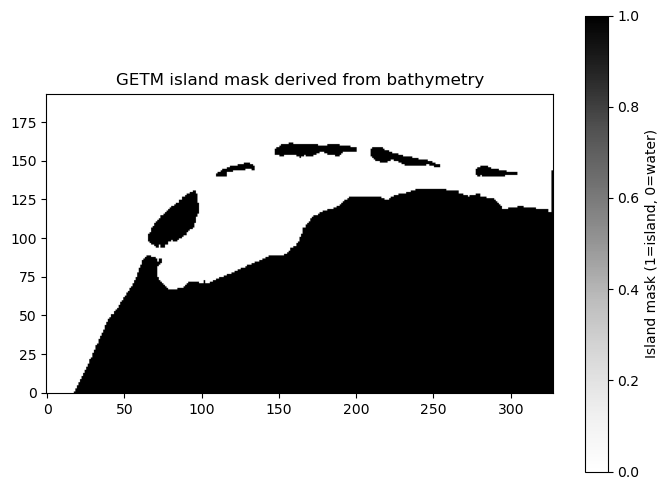

In [8]:
# Load topo and get target GETM grid
ds_topo = xr.open_dataset(topo_file)
lon_name, lat_name = detect_lon_lat_names(ds_topo)

lonc = ds_topo[lon_name].values
latc = ds_topo[lat_name].values
bathy_name = first_existing(['bathymetry', 'depth', 'bathy'], ds_topo.data_vars)
if bathy_name is None:
    raise ValueError('Could not detect bathymetry variable in topo dataset.')

bathy = np.asarray(ds_topo[bathy_name].values, dtype=float)
dim_xc, dim_yc = lonc.shape

# Robust mask for both NaN-based and masked-array bathymetry
island_mask = np.ma.getmaskarray(ds_topo[bathy_name].values) | np.isnan(bathy)

print(f'Grid shape: {lonc.shape}')
print(f'Island-mask count: {int(island_mask.sum())}')

plt.figure(figsize=(7, 5))
plt.imshow(island_mask.astype(float), origin='lower', cmap='Greys', vmin=0, vmax=1)
plt.colorbar(label='Island mask (1=island, 0=water)')
plt.title('GETM island mask derived from bathymetry')
plt.tight_layout()
plt.show()

Wadden porosity range: 0.38772889971733093 0.6693288087844849


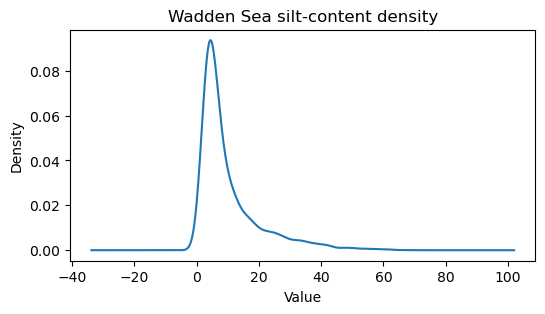

In [ ]:
# Load Wadden Sea sediment porosity
ds_ws = xr.open_dataset(silt_file)
mud_var = pick_data_var(ds_ws, preferred=['mud_fraction', 'silt_content', 'mud'])
por_var = pick_data_var(ds_ws, preferred=['porosity', 'Porosity'])

mud_arr = ds_ws[mud_var].squeeze(drop=True).values.astype(float)
ws_arr = ds_ws[por_var].squeeze(drop=True).values.astype(float)

mud_arr[mud_arr < 0] = np.nan
ws_arr[ws_arr < 0] = np.nan

# Align orientation if needed
if ws_arr.shape != lonc.shape:
    if ws_arr.T.shape == lonc.shape:
        ws_arr = ws_arr.T
        mud_arr = mud_arr.T
    else:
        raise ValueError(f'Wadden porosity shape {ws_arr.shape} does not match GETM grid {lonc.shape}')

df_ws = pd.DataFrame({
    'lon': lonc.ravel(),
    'lat': latc.ravel(),
    'Silt_content': mud_arr.ravel(),
    'porosity': ws_arr.ravel()
}).dropna(subset=['porosity'])

print('Wadden porosity range:', float(np.nanmin(ws_arr)), float(np.nanmax(ws_arr)))
plot_density(df_ws['Silt_content'], 'Wadden Sea silt-content density')

# Static inspection plots (no interactive map dependencies)

print_field_stats('Wadden Sea silt content (%)', mud_arr)
plot_grid(mud_arr, 'Wadden Sea silt content (%)', vmin=0, vmax=100)

print_field_stats('Wadden Sea porosity', ws_arr)
plot_grid(ws_arr, 'Wadden Sea porosity', vmin=0.35, vmax=0.70)


North Sea porosity range after interpolation: 0.40114501118659973 0.5
North Sea porosity (interpolated) stats:
  min=0.401145 max=0.500000
  q05=0.401145 q25=0.401145 q50=0.401145 q75=0.401145 q95=0.500000


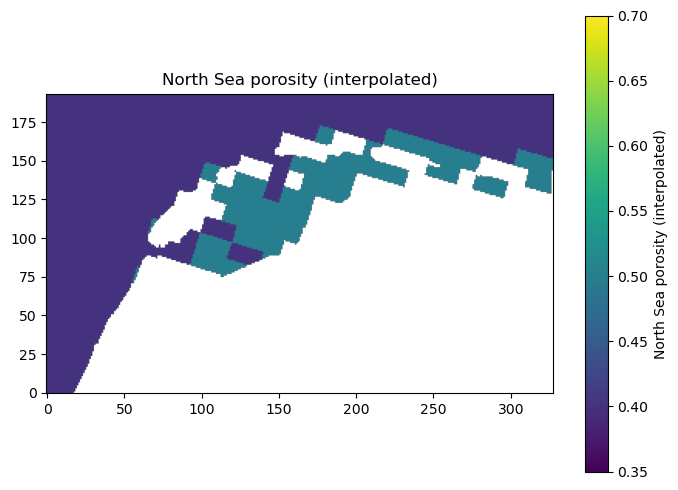

In [ ]:
# Load North Sea porosity and interpolate to GETM target points (old workflow)
ds_ns = xr.open_dataset(ns_file)
ns_var = pick_data_var(ds_ns, preferred=['Porosity', 'porosity'])
ns_da = ds_ns[ns_var].squeeze(drop=True)

lon_flat = lonc.ravel()
lat_flat = latc.ravel()

if use_constant_ns:
    ns_vals = np.full(lon_flat.shape, constant_ns_value, dtype=float)
else:
    ns_vals = interp_regular_grid_to_points(ns_da, lon_flat, lat_flat, method='nearest').astype(float)

ns_arr = ns_vals.reshape(lonc.shape)
ns_arr[island_mask] = np.nan

print('North Sea porosity range after interpolation:', float(np.nanmin(ns_arr)), float(np.nanmax(ns_arr)))
print_field_stats('North Sea porosity (interpolated)', ns_arr)
plot_grid(ns_arr, 'North Sea porosity (interpolated)', vmin=0.35, vmax=0.70)

Final porosity range: 0.38772889971733093 0.6693288087844849
Number of replaced cells: 8348
Merged final porosity stats:
  min=0.387729 max=0.669329
  q05=0.401112 q25=0.401145 q50=0.401145 q75=0.403102 q95=0.500000


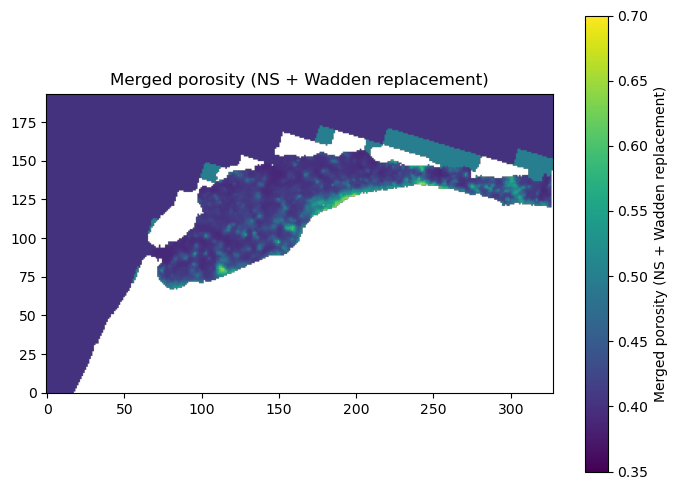

In [11]:
# Merge: overwrite NS with Wadden Sea porosity where available
final_porosity = ns_arr.copy()
replace_mask = ~np.isnan(ws_arr)
final_porosity[replace_mask] = ws_arr[replace_mask]
final_porosity[island_mask] = np.nan

df_final = pd.DataFrame({
    'lon': lonc.ravel(),
    'lat': latc.ravel(),
    'porosity': final_porosity.ravel()
}).dropna(subset=['porosity'])

print('Final porosity range:', float(np.nanmin(final_porosity)), float(np.nanmax(final_porosity)))
print('Number of replaced cells:', int(replace_mask.sum()))
print_field_stats('Merged final porosity', final_porosity)
plot_grid(final_porosity, 'Merged porosity (NS + Wadden replacement)', vmin=0.35, vmax=0.70)


Base porosity value: 0.401145
North Sea porosity (constant base + land mask) stats:
  min=0.401145 max=0.401145
  q05=0.401145 q25=0.401145 q50=0.401145 q75=0.401145 q95=0.401145


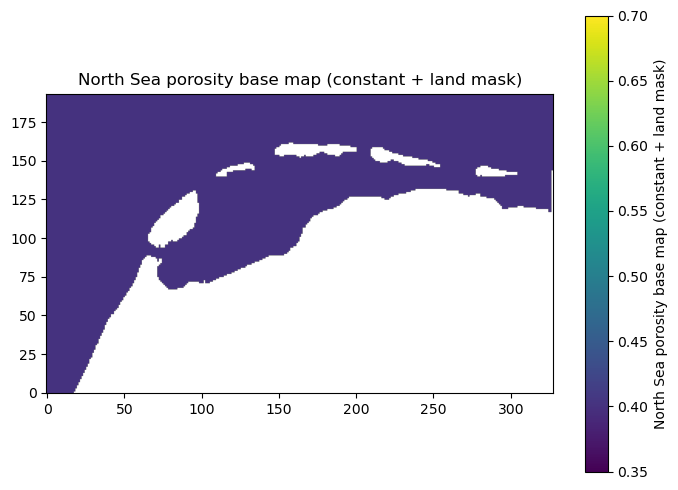

ns_arr updated from constant base map. Re-run Cell 11 and later cells to apply this baseline.


In [12]:
# Alternative North Sea base map: constant value on topo grid + land mask
base_porosity_value = 0.401145

ns_arr_base = np.full(lonc.shape, base_porosity_value, dtype=float)
ns_arr_base[island_mask] = np.nan

print(f'Base porosity value: {base_porosity_value}')
print_field_stats('North Sea porosity (constant base + land mask)', ns_arr_base)
plot_grid(ns_arr_base, 'North Sea porosity base map (constant + land mask)', vmin=0.35, vmax=0.70)

# Optional: make this base map the active NS field for merging
ns_arr = ns_arr_base.copy()
print('ns_arr updated from constant base map. Re-run Cell 11 and later cells to apply this baseline.')

Final porosity range: 0.38772889971733093 0.6693288087844849
Number of replaced cells: 8348
Merged final porosity stats:
  min=0.387729 max=0.669329
  q05=0.401145 q25=0.401145 q50=0.401145 q75=0.401145 q95=0.451477


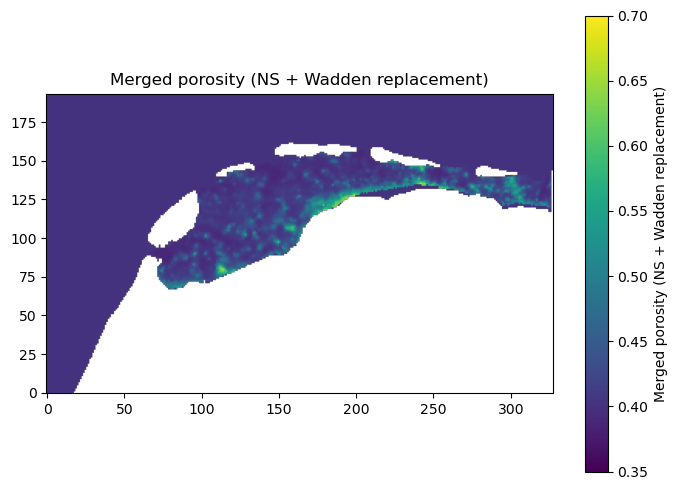

In [21]:
# Merge: overwrite NS with Wadden Sea porosity where available
final_porosity = ns_arr.copy()
replace_mask = ~np.isnan(ws_arr)
final_porosity[replace_mask] = ws_arr[replace_mask]
final_porosity[island_mask] = np.nan

df_final = pd.DataFrame({
    'lon': lonc.ravel(),
    'lat': latc.ravel(),
    'porosity': final_porosity.ravel()
}).dropna(subset=['porosity'])

print('Final porosity range:', float(np.nanmin(final_porosity)), float(np.nanmax(final_porosity)))
print('Number of replaced cells:', int(replace_mask.sum()))
print_field_stats('Merged final porosity', final_porosity)
plot_grid(final_porosity, 'Merged porosity (NS + Wadden replacement)', vmin=0.35, vmax=0.70)


In [22]:
# Save merged porosity to NetCDF
out_ds = xr.Dataset(
    data_vars={
        'porosity': (ds_topo[lon_name].dims, final_porosity.astype('float32'))
    },
    coords={
        lon_name: ds_topo[lon_name],
        lat_name: ds_topo[lat_name]
    },
    attrs={
        'title': 'Merged sediment porosity (North Sea + Wadden Sea replacement)',
        'source': 'Python translation of Sedprop workflow'
    }
)

output_file.parent.mkdir(parents=True, exist_ok=True)
out_ds.to_netcdf(output_file)
print(f'Saved: {output_file}')

Saved: /export/lv9/user/qzhan/home/GETM_ERSEM_SETUPS/dws_500m/Input/Ben_Sedprop.nc
